# 梯度下降算法实现

本笔记本将逐步实现梯度下降算法来最小化损失函数 $L(x, y) = (x-2)^2 + (y-3)^2$

## 1. 损失函数定义（2分）

定义函数 $L(x, y) = (x-2)^2 + (y-3)^2$。

In [1]:
# 定义损失函数
def L(x, y):
    """
    损失函数 L(x, y) = (x-2)^2 + (y-3)^2
    
    参数:
    x: x坐标值
    y: y坐标值
    
    返回:
    损失值
    """
    return (x - 2)**2 + (y - 3)**2

# 或者使用lambda表达式
L_lambda = lambda x, y: (x - 2)**2 + (y - 3)**2

# 测试函数
print(f'L(0, 0) = {L(0, 0)}')
print(f'L(2, 3) = {L(2, 3)}')  # 最小值点

L(0, 0) = 13
L(2, 3) = 0


## 2. 梯度计算（3分）

手动写出偏导数 $\partial L/\partial x = 2(x-2)$, $\partial L/\partial y = 2(y-3)$。

实现一个函数，给定 $(x,y)$ 返回梯度向量。

In [2]:
# 计算梯度的函数
def compute_gradient(x, y):
    """
    计算损失函数 L(x, y) = (x-2)^2 + (y-3)^2 的梯度
    
    偏导数:
    ∂L/∂x = 2(x-2)
    ∂L/∂y = 2(y-3)
    
    参数:
    x: x坐标值
    y: y坐标值
    
    返回:
    梯度向量 [∂L/∂x, ∂L/∂y]
    """
    grad_x = 2 * (x - 2)
    grad_y = 2 * (y - 3)
    return grad_x, grad_y

# 测试梯度计算
grad_x, grad_y = compute_gradient(0, 0)
print(f'在点(0, 0)处的梯度: ∂L/∂x = {grad_x}, ∂L/∂y = {grad_y}')

grad_x, grad_y = compute_gradient(2, 3)
print(f'在点(2, 3)处的梯度: ∂L/∂x = {grad_x}, ∂L/∂y = {grad_y}')  # 最小值点梯度应为0

在点(0, 0)处的梯度: ∂L/∂x = -4, ∂L/∂y = -6
在点(2, 3)处的梯度: ∂L/∂x = 0, ∂L/∂y = 0


## 3. 梯度下降算法（3分）

初始化起点（例如 $(0,0)$），设置学习率（如 $0.1$）和迭代次数（如 $50$）。

每次迭代：计算梯度，更新 $x = x - lr \times grad_x$, $y = y - lr \times grad_y$。

打印或记录每次迭代后的坐标和损失值。

In [7]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
from matplotlib import rcParams

# 设置中文字体支持
rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 使用微软雅黑
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 梯度下降算法实现
def gradient_descent(initial_x=0, initial_y=0, learning_rate=0.1, iterations=50):
    """
    梯度下降算法
    
    参数:
    initial_x: x的初始值
    initial_y: y的初始值
    learning_rate: 学习率
    iterations: 迭代次数
    
    返回:
    x_history: x的历史值列表
    y_history: y的历史值列表
    loss_history: 损失值的历史列表
    """
    # 初始化参数
    x = initial_x
    y = initial_y
    
    # 记录历史值
    x_history = [x]
    y_history = [y]
    loss_history = [L(x, y)]
    
    print(f'初始点: ({x}, {y}), 损失值: {L(x, y):.4f}')
    
    # 开始迭代
    for i in range(iterations):
        # 计算梯度
        grad_x, grad_y = compute_gradient(x, y)
        
        # 更新参数
        x = x - learning_rate * grad_x
        y = y - learning_rate * grad_y
        
        # 记录当前值
        x_history.append(x)
        y_history.append(y)
        loss = L(x, y)
        loss_history.append(loss)
        
        # 打印每10次迭代的结果
        if (i + 1) % 10 == 0:
            print(f'第{i+1}次迭代: 点({x:.4f}, {y:.4f}), 损失值: {loss:.4f}, 梯度: ({grad_x:.4f}, {grad_y:.4f})')
    
    print(f'最终点: ({x:.4f}, {y:.4f}), 损失值: {loss:.4f}')
    
    return x_history, y_history, loss_history

# 执行梯度下降
x_traj, y_traj, loss_traj = gradient_descent(initial_x=0, initial_y=0, learning_rate=0.1, iterations=50)

初始点: (0, 0), 损失值: 13.0000
第10次迭代: 点(1.7853, 2.6779), 损失值: 0.1499, 梯度: (-0.5369, -0.8053)
第20次迭代: 点(1.9769, 2.9654), 损失值: 0.0017, 梯度: (-0.0576, -0.0865)
第30次迭代: 点(1.9975, 2.9963), 损失值: 0.0000, 梯度: (-0.0062, -0.0093)
第40次迭代: 点(1.9997, 2.9996), 损失值: 0.0000, 梯度: (-0.0007, -0.0010)
第50次迭代: 点(2.0000, 3.0000), 损失值: 0.0000, 梯度: (-0.0001, -0.0001)
最终点: (2.0000, 3.0000), 损失值: 0.0000


## 4. 可视化（2分）

绘制损失函数的三维曲面图或等高线图。

在图上画出梯度下降的轨迹（点+连线）。

使用 matplotlib 完成。

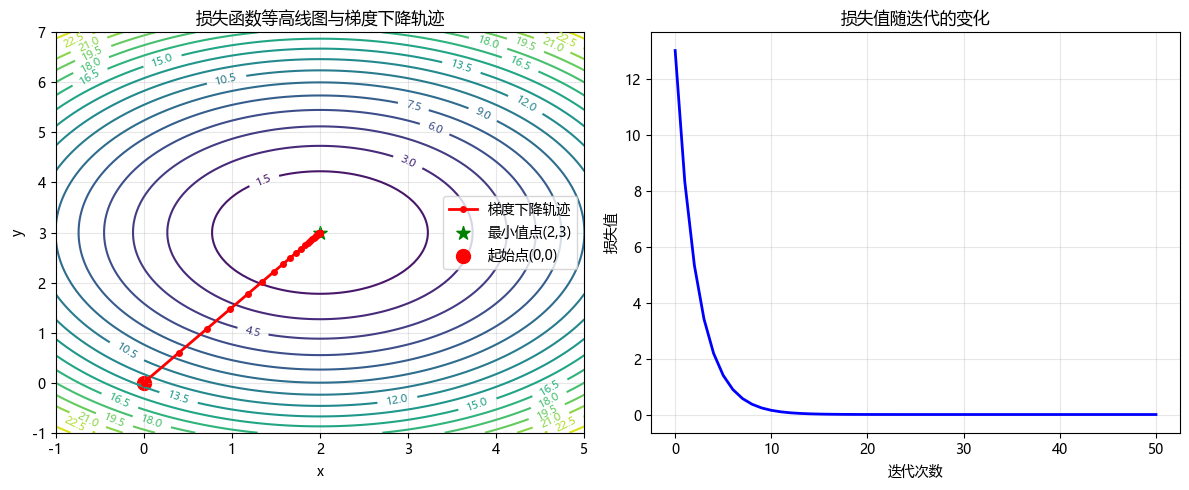

In [8]:
# 等高线图可视化
plt.figure(figsize=(12, 5))

# 子图1: 等高线图
plt.subplot(1, 2, 1)
x_range = np.linspace(-1, 5, 100)
y_range = np.linspace(-1, 7, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = L(X, Y)

contour = plt.contour(X, Y, Z, levels=20)
plt.clabel(contour, inline=True, fontsize=8)

# 绘制梯度下降轨迹
plt.plot(x_traj, y_traj, 'ro-', markersize=4, linewidth=2, label='梯度下降轨迹')
plt.scatter([2], [3], color='green', s=100, marker='*', label='最小值点(2,3)')
plt.scatter([0], [0], color='red', s=100, marker='o', label='起始点(0,0)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('损失函数等高线图与梯度下降轨迹')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 损失值随迭代次数变化
plt.subplot(1, 2, 2)
plt.plot(loss_traj, 'b-', linewidth=2)
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.title('损失值随迭代的变化')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

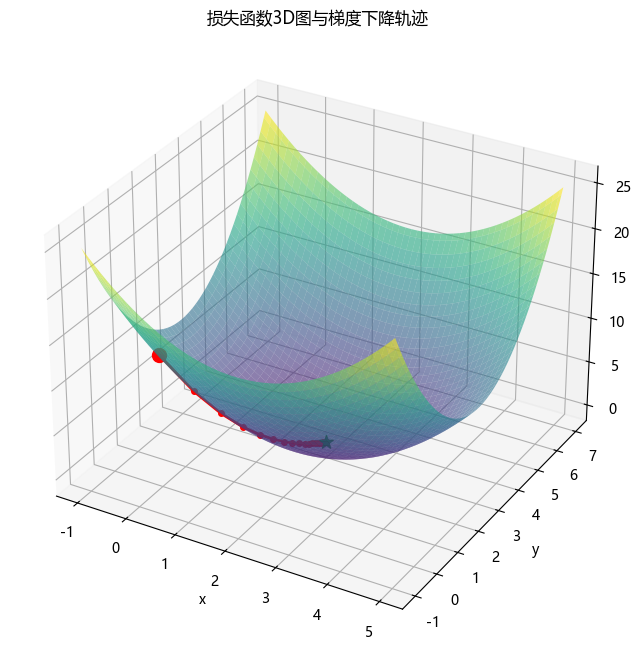

In [9]:
# 3D可视化
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制损失函数表面
x_range = np.linspace(-1, 5, 100)
y_range = np.linspace(-1, 7, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = L(X, Y)

ax.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')

# 绘制梯度下降轨迹
ax.plot(x_traj, y_traj, loss_traj, 'ro-', markersize=4, linewidth=2, label='梯度下降轨迹')
ax.scatter([2], [3], [L(2, 3)], color='green', s=100, marker='*', label='最小值点(2,3)')
ax.scatter([0], [0], [L(0, 0)], color='red', s=100, marker='o', label='起始点(0,0)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('L(x,y)')
ax.set_title('损失函数3D图与梯度下降轨迹')
# 注意：legend在3D图中可能不完全正常工作，所以添加文本标注

plt.show()

## 总结

我们成功实现了梯度下降算法来最小化损失函数 $L(x, y) = (x-2)^2 + (y-3)^2$：

1. 定义了损失函数 $L(x, y) = (x-2)^2 + (y-3)^2$
2. 计算了偏导数 $\partial L/\partial x = 2(x-2)$ 和 $\partial L/\partial y = 2(y-3)$
3. 实现了梯度下降算法，从初始点$(0,0)$开始，经过50次迭代后收敛到接近$(2,3)$的点
4. 使用matplotlib绘制了等高线图、损失值变化曲线和3D曲面图来可视化梯度下降过程